In [ ]:
pip install sklearn

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
# Load California Housing dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Feature names:", housing.feature_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape of X: (20640, 8)
Shape of y: (20640,)


In [8]:
# Create a dataframe for quick inspection
df = pd.DataFrame(X, columns=housing.feature_names)
df["Target"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


In [10]:
# Standardize the feature values
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

X_train_tensor shape: torch.Size([16512, 8])
y_train_tensor shape: torch.Size([16512, 1])


In [12]:
class HousingRegressionModel(nn.Module):
    def __init__(self):
        super(HousingRegressionModel, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model = HousingRegressionModel()
print(model)

HousingRegressionModel(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [13]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    model.train()

    # Forward pass
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 3.7759
Epoch [20/100], Loss: 2.6239
Epoch [30/100], Loss: 1.7312
Epoch [40/100], Loss: 1.2054
Epoch [50/100], Loss: 0.9338
Epoch [60/100], Loss: 0.8104
Epoch [70/100], Loss: 0.7625
Epoch [80/100], Loss: 0.7273
Epoch [90/100], Loss: 0.6939
Epoch [100/100], Loss: 0.6628


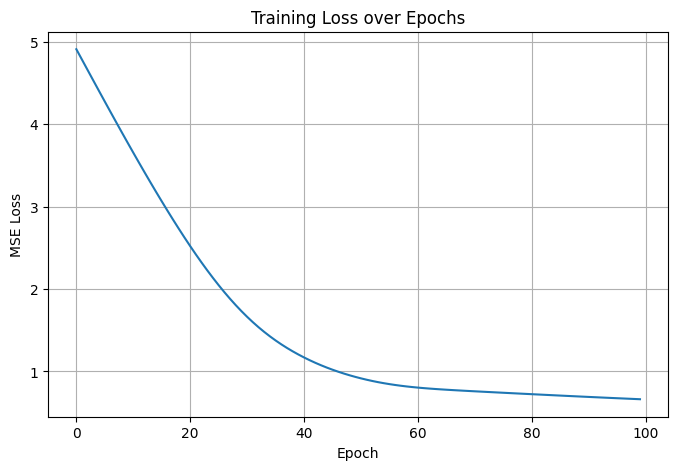

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [16]:
model.eval()

with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)

y_pred = y_pred_tensor.numpy()
y_true = y_test_tensor.numpy()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R^2  : {r2:.4f}")

MSE  : 0.6684
RMSE : 0.8176
MAE  : 0.5941
R^2  : 0.4899


In [17]:
results_df = pd.DataFrame({
    "Actual": y_true.flatten(),
    "Predicted": y_pred.flatten()
})

results_df.head(10)

,Actual,Predicted
0,0.47700,0.771190
1,0.45800,0.965346
2,5.00001,2.454180
3,2.18600,2.396754
4,2.78000,1.847505
5,1.58700,2.127764
6,1.98200,2.452813
7,1.57500,1.995886
8,3.40000,2.281874
9,4.46600,4.194530


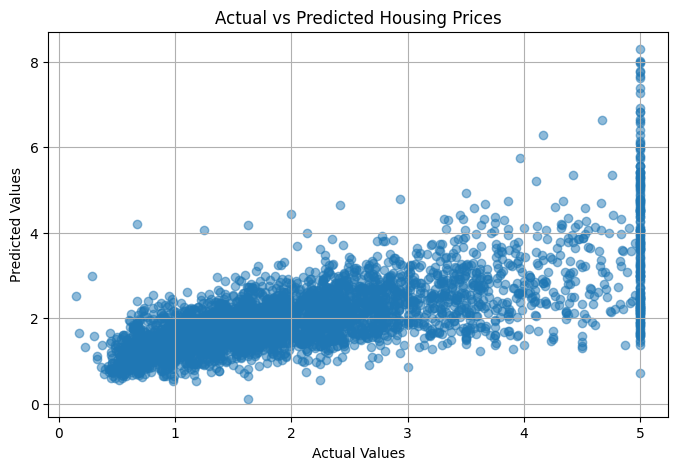

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Housing Prices")
plt.grid(True)
plt.show()

In [19]:
for i in range(5):
    print(f"Sample {i+1}")
    print(f"Actual Value   : {y_true[i][0]:.3f}")
    print(f"Predicted Value: {y_pred[i][0]:.3f}")
    print("-" * 30)

Sample 1
Actual Value   : 0.477
Predicted Value: 0.771
------------------------------
Sample 2
Actual Value   : 0.458
Predicted Value: 0.965
------------------------------
Sample 3
Actual Value   : 5.000
Predicted Value: 2.454
------------------------------
Sample 4
Actual Value   : 2.186
Predicted Value: 2.397
------------------------------
Sample 5
Actual Value   : 2.780
Predicted Value: 1.848
------------------------------


### Conclusion

This notebook adapted a PyTorch regression workflow to the California Housing dataset.  
The dataset required preprocessing steps such as train-test splitting, feature scaling, and conversion into PyTorch tensors.  
A simple feedforward neural network was trained to predict median house values.  
The model produced reasonable results, but further tuning, regularization, and validation would be needed before considering deployment in a real-world setting.

In [20]:
import torch
import joblib

torch.save(model.state_dict(), "housing_model.pth")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']